# UK Leasehold Expiry Analysis - Heat Map

This notebook analyzes leasehold expiry dates and creates a heat map showing the percentage of leases with remaining years < 100 for each UK district.

## Overview

- **Data Source**: MongoDB collection (`leases.leases`) containing ~7 million lease documents
- **Required Fields**: `location` (GeoJSON Point) and `expiry_date` fields
- **Analysis**: Calculate remaining lease years from today (February 25, 2026)
- **Output**: Interactive heat map of UK districts showing percentage of leases with < 100 years remaining

## Prerequisites

1. MongoDB running locally on `mongodb://localhost:27017`
2. `.env` file in the project root with connection details
3. Districts GeoJSON file at `data/districts.geojson`


---
## 1. Setup and Imports

Import all necessary libraries for data processing, spatial analysis, and visualization.


In [2]:
# Standard library imports
import os
import json
from pathlib import Path
from collections import defaultdict
from datetime import datetime

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pymongo import MongoClient
from dotenv import load_dotenv
from tqdm.notebook import tqdm

# For coordinate transformation (BNG to WGS84)
from pyproj import Transformer

# For geometric operations
from shapely.geometry import shape, Point
from shapely.prepared import prep
from shapely.strtree import STRtree

# For plotting maps
import geopandas as gpd

print("✓ All imports completed successfully!")


✓ All imports completed successfully!


---
## 2. Configuration

Load connection details from the `.env` file and set up paths.


In [3]:
# Load environment variables from .env file
env_path = Path("../.env")
load_dotenv(env_path)

# MongoDB Configuration - load from env or use defaults
MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")
MONGO_DATABASE = os.getenv("MONGO_DATABASE", "leases")
MONGO_COLLECTION = os.getenv("MONGO_COLLECTION", "leases")

# File paths
DATA_DIR = Path("data")
DISTRICTS_GEOJSON_PATH = DATA_DIR / "districts.geojson"

# Processing configuration
BATCH_SIZE = 50000  # Number of documents to process at a time
TODAY = datetime(2026, 2, 25)  # Current date for calculations

# Analysis threshold
YEARS_THRESHOLD = 100  # Threshold for "short" leases

print(f"MongoDB URI: {MONGO_URI}")
print(f"Database: {MONGO_DATABASE}")
print(f"Collection: {MONGO_COLLECTION}")
print(f"Districts GeoJSON: {DISTRICTS_GEOJSON_PATH}")
print(f"Batch size: {BATCH_SIZE:,}")
print(f"Today's date: {TODAY.strftime('%B %d, %Y')}")
print(f"Threshold: Leases with < {YEARS_THRESHOLD} years remaining")


MongoDB URI: mongodb://localhost:27017
Database: leases
Collection: leases
Districts GeoJSON: data/districts.geojson
Batch size: 50,000
Today's date: February 25, 2026
Threshold: Leases with < 100 years remaining


---
## 3. Connect to MongoDB

Establish a connection to the local MongoDB instance and verify the collection exists.


In [4]:
# Connect to MongoDB
client = MongoClient(MONGO_URI)
db = client[MONGO_DATABASE]
collection = db[MONGO_COLLECTION]

# Verify connection and get collection stats
total_documents = collection.estimated_document_count()
print(f"✓ Connected to MongoDB successfully!")
print(f"Total documents in collection: {total_documents:,}")

# Count documents with required fields
docs_with_location = collection.count_documents({"location": {"$exists": True, "$ne": None}})
docs_with_expiry = collection.count_documents({"expiry_date": {"$exists": True, "$ne": None}})
docs_with_both = collection.count_documents({
    "location": {"$exists": True, "$ne": None},
    "expiry_date": {"$exists": True, "$ne": None}
})

print(f"\nDocuments with location field: {docs_with_location:,}")
print(f"Documents with expiry_date field: {docs_with_expiry:,}")
print(f"Documents with both fields: {docs_with_both:,}")
print(f"Percentage with both: {docs_with_both/total_documents*100:.1f}%")


✓ Connected to MongoDB successfully!
Total documents in collection: 6,711,969

Documents with location field: 6,415,947
Documents with expiry_date field: 6,657,790
Documents with both fields: 6,365,297
Percentage with both: 94.8%


---
## 4. Sample Document Inspection

Let's examine a few documents to understand the structure of location and expiry_date fields.


In [8]:
# Get a sample document with both fields
sample_doc = collection.find_one({
    "location": {"$exists": True},
    "expiry_date": {"$exists": True}
})

if sample_doc:
    print("Sample document fields:")
    print("\n1. Location field:")
    print(json.dumps(sample_doc.get('location'), indent=2))

    print("\n2. Expiry date field:")
    expiry = sample_doc.get('expiry_date')
    print(f"Value: {expiry}")
    print(f"Type: {type(expiry)}")

    # Try to parse expiry date
    if isinstance(expiry, datetime):
        print(f"Already a datetime object: {expiry}")
        years_remaining = (expiry - TODAY).days / 365.25
        print(f"Years remaining: {years_remaining:.1f}")
    elif isinstance(expiry, str):
        print(f"String format, needs parsing")
else:
    print("No documents with both location and expiry_date found!")


Sample document fields:

1. Location field:
{
  "type": "Point",
  "coordinates": [
    -0.0294264,
    51.5153806
  ]
}

2. Expiry date field:
Value: 1961-06-24 00:00:00
Type: <class 'datetime.datetime'>
Already a datetime object: 1961-06-24 00:00:00
Years remaining: -64.7


---
## 5. Load Districts GeoJSON

Load the UK districts boundaries from the GeoJSON file. The districts are in British National Grid (EPSG:27700).


In [9]:
# Load the districts GeoJSON
print(f"Loading districts from: {DISTRICTS_GEOJSON_PATH}")

with open(DISTRICTS_GEOJSON_PATH, 'r') as f:
    districts_geojson = json.load(f)

# Check the CRS (Coordinate Reference System)
crs = districts_geojson.get('crs', {})
print(f"GeoJSON CRS: {crs}")

# Count districts
num_districts = len(districts_geojson['features'])
print(f"\nTotal number of districts: {num_districts}")

# Preview some district names
print("\nSample districts:")
for feature in districts_geojson['features'][:5]:
    props = feature['properties']
    print(f"  - {props.get('LAD24NM', 'Unknown')} ({props.get('LAD24CD', 'N/A')})")


Loading districts from: data/districts.geojson
GeoJSON CRS: {'type': 'name', 'properties': {'name': 'EPSG:27700'}}

Total number of districts: 361

Sample districts:
  - Hartlepool (E06000001)
  - Middlesbrough (E06000002)
  - Redcar and Cleveland (E06000003)
  - Stockton-on-Tees (E06000004)
  - Darlington (E06000005)


---
## 6. Transform District Coordinates

Transform district boundaries from British National Grid (EPSG:27700) to WGS84 (EPSG:4326) to match MongoDB location data.


In [10]:
def transform_coordinates_bng_to_wgs84(geometry, transformer):
    """
    Transform geometry coordinates from BNG (EPSG:27700) to WGS84 (EPSG:4326).
    Handles Polygon and MultiPolygon geometries.
    """
    geom_type = geometry['type']

    if geom_type == 'Polygon':
        new_coords = []
        for ring in geometry['coordinates']:
            new_ring = []
            for coord in ring:
                lon, lat = transformer.transform(coord[0], coord[1])
                new_ring.append([lon, lat])
            new_coords.append(new_ring)
        return {'type': 'Polygon', 'coordinates': new_coords}

    elif geom_type == 'MultiPolygon':
        new_polygons = []
        for polygon in geometry['coordinates']:
            new_rings = []
            for ring in polygon:
                new_ring = []
                for coord in ring:
                    lon, lat = transformer.transform(coord[0], coord[1])
                    new_ring.append([lon, lat])
                new_rings.append(new_ring)
            new_polygons.append(new_rings)
        return {'type': 'MultiPolygon', 'coordinates': new_polygons}

    else:
        raise ValueError(f"Unsupported geometry type: {geom_type}")


# Create transformer from BNG to WGS84
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

# Transform all district geometries
print("Transforming district coordinates from BNG to WGS84...")

districts = []
for feature in tqdm(districts_geojson['features'], desc="Transforming districts"):
    props = feature['properties']

    # Transform geometry
    transformed_geom = transform_coordinates_bng_to_wgs84(feature['geometry'], transformer)

    # Create shapely geometry and prepare it for faster queries
    geom = shape(transformed_geom)

    districts.append({
        'code': props.get('LAD24CD', 'Unknown'),
        'name': props.get('LAD24NM', 'Unknown'),
        'geometry': geom,
        'prepared': prep(geom)  # Prepared geometry for faster intersection tests
    })

print(f"\n✓ Transformed {len(districts)} districts to WGS84")


Transforming district coordinates from BNG to WGS84...


Transforming districts:   0%|          | 0/361 [00:00<?, ?it/s]


✓ Transformed 361 districts to WGS84


---
## 7. Build Spatial Index

Create a spatial index (R-tree) for efficient point-in-polygon queries.


In [11]:
# Build spatial index using STRtree
print("Building spatial index...")

geometries = [d['geometry'] for d in districts]
spatial_index = STRtree(geometries)

# Create a mapping from geometry id to district index
geom_to_district = {id(geom): i for i, geom in enumerate(geometries)}

print(f"✓ Spatial index built with {len(geometries)} district polygons")


Building spatial index...
✓ Spatial index built with 361 district polygons


---
## 8. Helper Functions

Define functions for district lookup and expiry date parsing.


In [12]:
def find_district(point, spatial_index, districts, geom_to_district):
    """
    Find which district a point belongs to using spatial index.
    Returns district code and name, or None if not found.
    """
    # Query spatial index for candidate districts
    candidate_indices = spatial_index.query(point)

    for idx in candidate_indices:
        district = districts[idx]
        # Use prepared geometry for faster containment check
        if district['prepared'].contains(point):
            return district['code'], district['name']

    return None, None


def parse_expiry_date(expiry_value):
    """
    Parse expiry date from various formats.
    Returns datetime object or None if invalid.
    """
    if expiry_value is None:
        return None

    # Already a datetime object
    if isinstance(expiry_value, datetime):
        return expiry_value

    # Try parsing string formats
    if isinstance(expiry_value, str):
        # Common date formats to try
        formats = [
            '%Y-%m-%d',
            '%Y/%m/%d',
            '%d-%m-%Y',
            '%d/%m/%Y',
            '%Y-%m-%dT%H:%M:%S',
            '%Y-%m-%dT%H:%M:%S.%f',
        ]

        for fmt in formats:
            try:
                return datetime.strptime(expiry_value, fmt)
            except ValueError:
                continue

    # Try converting integer (year only)
    if isinstance(expiry_value, (int, float)):
        try:
            year = int(expiry_value)
            if 1900 <= year <= 3000:
                return datetime(year, 1, 1)
        except:
            pass

    return None


def calculate_years_remaining(expiry_date, today=TODAY):
    """
    Calculate years remaining from today to expiry date.
    Returns float or None if invalid.
    """
    if expiry_date is None:
        return None

    days_remaining = (expiry_date - today).days
    years_remaining = days_remaining / 365.25

    return years_remaining

print("✓ Helper functions defined")


✓ Helper functions defined


---
## 9. Process All Leases

Process all documents with location and expiry_date to calculate statistics by district.


In [13]:
# Initialize data structures
district_data = defaultdict(lambda: {
    'total': 0,
    'under_threshold': 0,
    'valid_expiry': 0,
    'name': None
})

no_location_count = 0
no_expiry_count = 0
no_district_found = 0
invalid_expiry_count = 0
processed_count = 0
error_count = 0

# Query documents with both location and expiry_date
query = {
    "location": {"$exists": True, "$ne": None},
    "expiry_date": {"$exists": True, "$ne": None}
}
projection = {"location": 1, "expiry_date": 1, "_id": 0}

print(f"Processing {docs_with_both:,} documents with location and expiry_date...")
print(f"Using batch size: {BATCH_SIZE:,}")
print()

# Process documents in batches
cursor = collection.find(query, projection).batch_size(BATCH_SIZE)

with tqdm(total=docs_with_both, desc="Processing leaseholds") as pbar:
    for doc in cursor:
        processed_count += 1

        try:
            location = doc.get('location')
            expiry_value = doc.get('expiry_date')

            # Validate location
            if not location or not isinstance(location, dict):
                no_location_count += 1
                pbar.update(1)
                continue

            coords = location.get('coordinates')
            if not coords or len(coords) < 2:
                no_location_count += 1
                pbar.update(1)
                continue

            # Create point (longitude, latitude)
            point = Point(coords[0], coords[1])

            # Find district
            district_code, district_name = find_district(
                point, spatial_index, districts, geom_to_district
            )

            if not district_code:
                no_district_found += 1
                pbar.update(1)
                continue

            # Parse expiry date
            expiry_date = parse_expiry_date(expiry_value)

            if expiry_date is None:
                invalid_expiry_count += 1
                # Still count it in the district total
                district_data[district_code]['total'] += 1
                district_data[district_code]['name'] = district_name
                pbar.update(1)
                continue

            # Calculate years remaining
            years_remaining = calculate_years_remaining(expiry_date)

            # Update district statistics
            district_data[district_code]['total'] += 1
            district_data[district_code]['valid_expiry'] += 1
            district_data[district_code]['name'] = district_name

            if years_remaining is not None and years_remaining < YEARS_THRESHOLD:
                district_data[district_code]['under_threshold'] += 1

        except Exception as e:
            error_count += 1
            if error_count <= 5:  # Only print first 5 errors
                print(f"\nError processing document: {e}")

        pbar.update(1)

print(f"\n✓ Processing complete!")
print(f"  Total processed: {processed_count:,}")
print(f"  Assigned to district: {sum(d['total'] for d in district_data.values()):,}")
print(f"  With valid expiry dates: {sum(d['valid_expiry'] for d in district_data.values()):,}")
print(f"  Under {YEARS_THRESHOLD} years threshold: {sum(d['under_threshold'] for d in district_data.values()):,}")
print(f"  Invalid/missing location: {no_location_count:,}")
print(f"  Outside districts: {no_district_found:,}")
print(f"  Invalid expiry dates: {invalid_expiry_count:,}")
print(f"  Errors: {error_count:,}")


Processing 6,365,297 documents with location and expiry_date...
Using batch size: 50,000



Processing leaseholds:   0%|          | 0/6365297 [00:00<?, ?it/s]


✓ Processing complete!
  Total processed: 6,365,297
  Assigned to district: 6,324,655
  With valid expiry dates: 6,324,655
  Under 100 years threshold: 1,848,676
  Invalid/missing location: 0
  Outside districts: 40,642
  Invalid expiry dates: 0
  Errors: 0


---
## 10. Create Results DataFrame

Calculate percentages and create a DataFrame with results.


In [14]:
# Create DataFrame from results
results_data = []

for district_code, data in district_data.items():
    # Calculate percentage
    if data['valid_expiry'] > 0:
        percentage_under_threshold = (data['under_threshold'] / data['valid_expiry']) * 100
    else:
        percentage_under_threshold = None

    results_data.append({
        'district_code': district_code,
        'district_name': data['name'],
        'total_leases': data['total'],
        'valid_expiry_count': data['valid_expiry'],
        'under_threshold_count': data['under_threshold'],
        'percentage_under_threshold': percentage_under_threshold
    })

# Create DataFrame and sort by percentage
df_results = pd.DataFrame(results_data)
df_results = df_results.sort_values('percentage_under_threshold', ascending=False).reset_index(drop=True)

# Add ranking
df_results['rank'] = df_results.index + 1
df_results = df_results[[
    'rank', 'district_code', 'district_name', 'total_leases',
    'valid_expiry_count', 'under_threshold_count', 'percentage_under_threshold'
]]

print(f"Results DataFrame: {len(df_results)} districts with leasehold data")
print(f"Total leaseholds: {df_results['total_leases'].sum():,}")
print(f"Districts with valid expiry data: {df_results['valid_expiry_count'].notna().sum()}")


Results DataFrame: 319 districts with leasehold data
Total leaseholds: 6,324,655
Districts with valid expiry data: 319


---
## 11. Summary Statistics

Display summary statistics about the lease expiry analysis.


In [15]:
print("=" * 80)
print("LEASE EXPIRY ANALYSIS - SUMMARY STATISTICS")
print("=" * 80)

valid_data = df_results[df_results['percentage_under_threshold'].notna()]

print(f"\nTotal districts analyzed: {len(valid_data):,}")
print(f"Total leases with valid expiry: {valid_data['valid_expiry_count'].sum():,}")
print(f"Total leases under {YEARS_THRESHOLD} years: {valid_data['under_threshold_count'].sum():,}")

overall_percentage = (valid_data['under_threshold_count'].sum() / valid_data['valid_expiry_count'].sum()) * 100
print(f"\nOverall percentage under {YEARS_THRESHOLD} years: {overall_percentage:.2f}%")

print(f"\nPercentage Statistics (by district):")
print(f"  Mean: {valid_data['percentage_under_threshold'].mean():.2f}%")
print(f"  Median: {valid_data['percentage_under_threshold'].median():.2f}%")
print(f"  Std Dev: {valid_data['percentage_under_threshold'].std():.2f}%")
print(f"  Min: {valid_data['percentage_under_threshold'].min():.2f}% ({valid_data.iloc[-1]['district_name']})")
print(f"  Max: {valid_data['percentage_under_threshold'].max():.2f}% ({valid_data.iloc[0]['district_name']})")


LEASE EXPIRY ANALYSIS - SUMMARY STATISTICS

Total districts analyzed: 319
Total leases with valid expiry: 6,324,655
Total leases under 100 years: 1,848,676

Overall percentage under 100 years: 29.23%

Percentage Statistics (by district):
  Mean: 36.10%
  Median: 34.22%
  Std Dev: 14.68%
  Min: 4.03% (Pendle)
  Max: 100.00% (Fife)


---
## 12. View Top and Bottom Districts

Display districts with highest and lowest percentages of short leases.


In [16]:
# Display top 20 districts
print("\n" + "=" * 100)
print(f"TOP 20 DISTRICTS - HIGHEST PERCENTAGE OF LEASES < {YEARS_THRESHOLD} YEARS")
print("=" * 100)
display(df_results.head(20))



TOP 20 DISTRICTS - HIGHEST PERCENTAGE OF LEASES < 100 YEARS


,rank,district_code,district_name,total_leases,valid_expiry_count,under_threshold_count,percentage_under_threshold
0,1,S12000047,Fife,2,2,2,100.000000
1,2,W06000016,Rhondda Cynon Taf,7479,7479,5671,75.825645
2,3,E07000192,Cannock Chase,6828,6828,5121,75.000000
3,4,E07000199,Tamworth,6607,6607,4954,74.981081
4,5,W06000018,Caerphilly,8848,8848,6616,74.773960
5,6,E07000236,Redditch,7379,7379,5235,70.944572
6,7,E06000012,North East Lincolnshire,9020,9020,6347,70.365854
7,8,W06000012,Neath Port Talbot,6484,6484,4518,69.679210
8,9,W06000013,Bridgend,7724,7724,5318,68.850337
9,10,E07000234,Bromsgrove,6455,6455,4307,66.723470


In [17]:
# Display bottom 20 districts
print("\n" + "=" * 100)
print(f"BOTTOM 20 DISTRICTS - LOWEST PERCENTAGE OF LEASES < {YEARS_THRESHOLD} YEARS")
print("=" * 100)
display(df_results[df_results['percentage_under_threshold'].notna()].tail(20))



BOTTOM 20 DISTRICTS - LOWEST PERCENTAGE OF LEASES < 100 YEARS


,rank,district_code,district_name,total_leases,valid_expiry_count,under_threshold_count,percentage_under_threshold
299,300,E06000023,"Bristol, City of",65047,65047,8754,13.457961
300,301,E08000034,Kirklees,47573,47573,5294,11.128161
301,302,E08000007,Stockport,53568,53568,5543,10.347596
302,303,E08000014,Sefton,41911,41911,4302,10.264608
303,304,E08000009,Trafford,54057,54057,5122,9.475184
304,305,E07000124,Ribble Valley,8373,8373,787,9.399260
305,306,E08000008,Tameside,34546,34546,3045,8.814335
306,307,E08000006,Salford,90609,90609,7602,8.389895
307,308,E08000013,St. Helens,42491,42491,3292,7.747523
308,309,E07000037,High Peak,15478,15478,1189,7.681871


---
## 13. Create UK Heat Map

Generate a choropleth heat map showing the percentage of leases with < 100 years remaining by district.


In [18]:
# Create GeoDataFrame with original BNG coordinates for plotting
gdf_districts = gpd.GeoDataFrame.from_features(districts_geojson['features'])

# Ensure we have the correct district code column
if 'LAD24CD' in gdf_districts.columns:
    gdf_districts = gdf_districts.rename(columns={'LAD24CD': 'district_code'})

# Merge with our results
gdf_merged = gdf_districts.merge(
    df_results[['district_code', 'percentage_under_threshold', 'valid_expiry_count', 'under_threshold_count']],
    on='district_code',
    how='left'
)

# Set CRS (British National Grid)
gdf_merged = gdf_merged.set_crs('EPSG:27700')

print(f"GeoDataFrame created with {len(gdf_merged)} districts")
print(f"Districts with data: {gdf_merged['percentage_under_threshold'].notna().sum()}")


GeoDataFrame created with 361 districts
Districts with data: 319


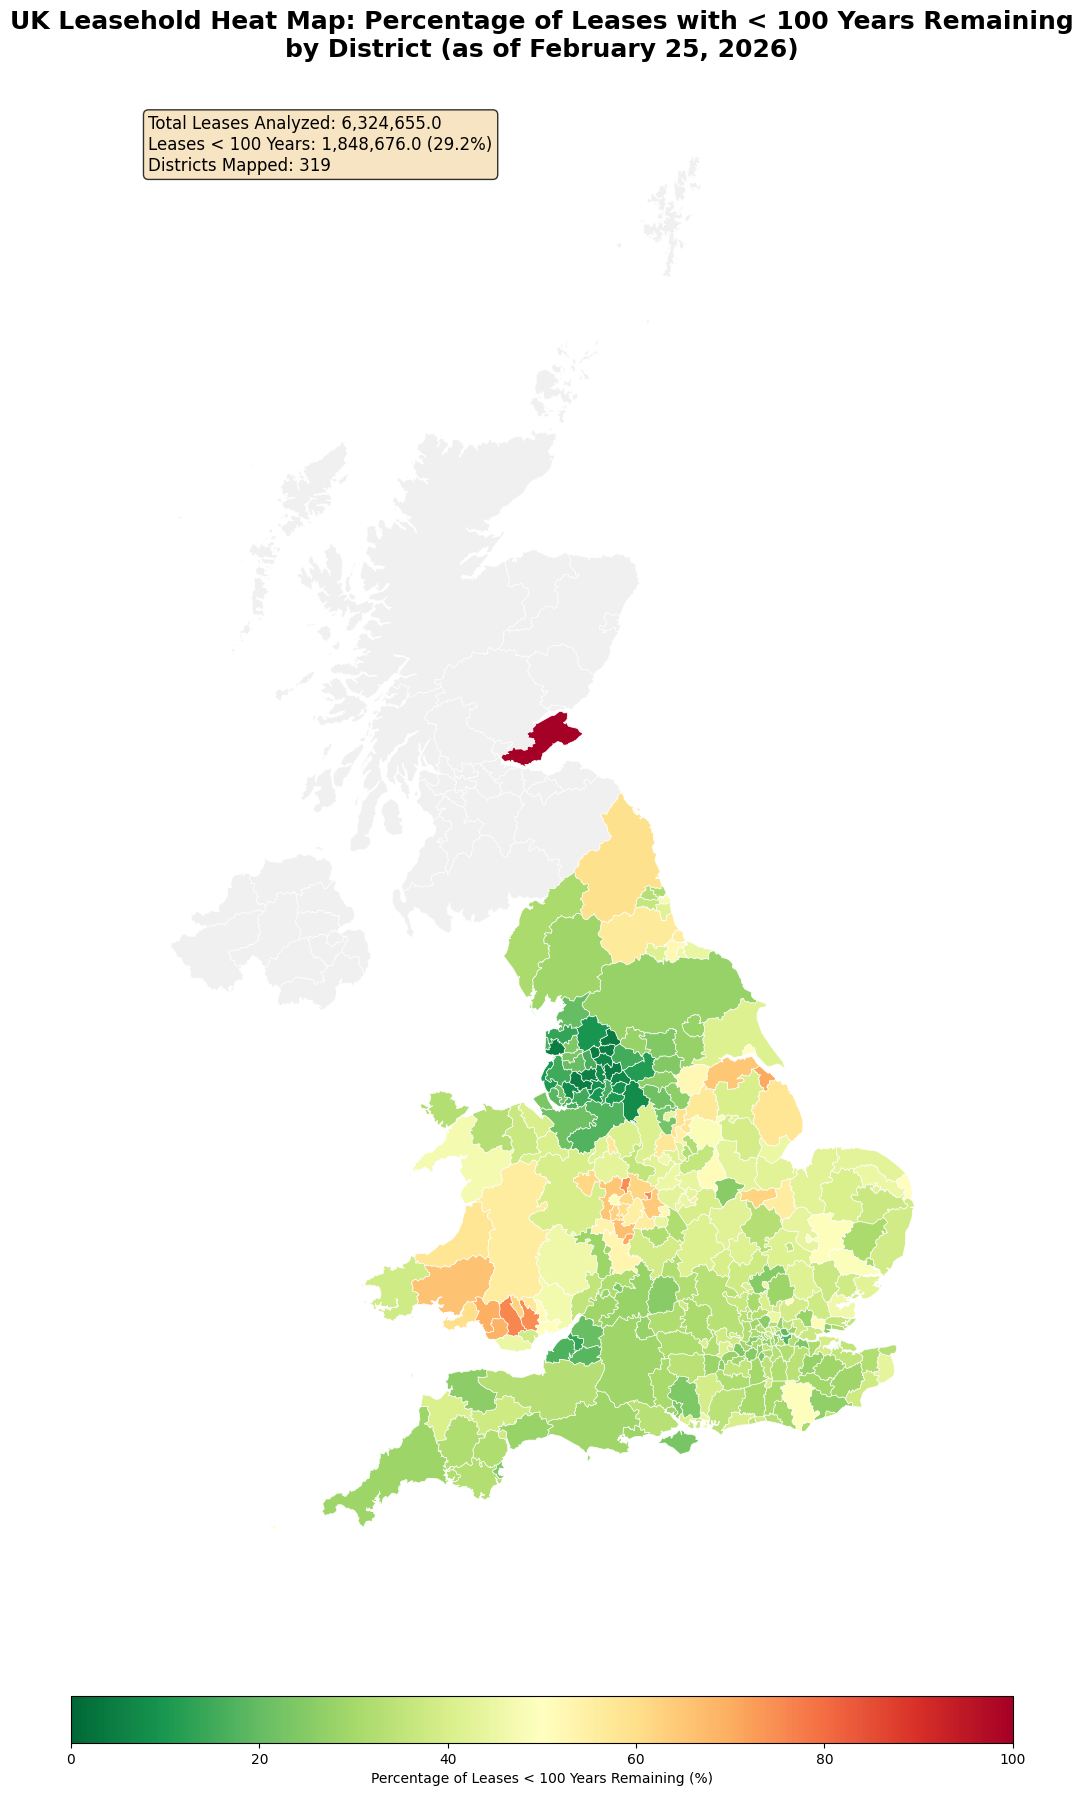

In [19]:
# Create the heat map
fig, ax = plt.subplots(1, 1, figsize=(16, 20))

# Plot districts with data
gdf_with_data = gdf_merged[gdf_merged['percentage_under_threshold'].notna()]
gdf_no_data = gdf_merged[gdf_merged['percentage_under_threshold'].isna()]

# Plot districts without data in light gray
gdf_no_data.plot(
    ax=ax,
    color='#f0f0f0',
    edgecolor='white',
    linewidth=0.5
)

# Plot districts with data using a color scale
gdf_with_data.plot(
    ax=ax,
    column='percentage_under_threshold',
    cmap='RdYlGn_r',  # Red-Yellow-Green reversed (red = high percentage)
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    vmin=0,
    vmax=100,
    legend_kwds={
        'label': f'Percentage of Leases < {YEARS_THRESHOLD} Years Remaining (%)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.05
    }
)

# Styling
ax.set_title(
    f'UK Leasehold Heat Map: Percentage of Leases with < {YEARS_THRESHOLD} Years Remaining\n'
    f'by District (as of {TODAY.strftime("%B %d, %Y")})',
    fontsize=18,
    fontweight='bold',
    pad=20
)
ax.axis('off')

# Add text annotation
total_analyzed = gdf_with_data['valid_expiry_count'].sum()
total_under = gdf_with_data['under_threshold_count'].sum()
overall_pct = (total_under / total_analyzed * 100) if total_analyzed > 0 else 0

text_str = f'Total Leases Analyzed: {total_analyzed:,}\n'
text_str += f'Leases < {YEARS_THRESHOLD} Years: {total_under:,} ({overall_pct:.1f}%)\n'
text_str += f'Districts Mapped: {len(gdf_with_data)}'

ax.text(
    0.02, 0.98,
    text_str,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

plt.tight_layout()
plt.show()


---
## 14. Distribution Histogram

Show the distribution of percentages across districts.


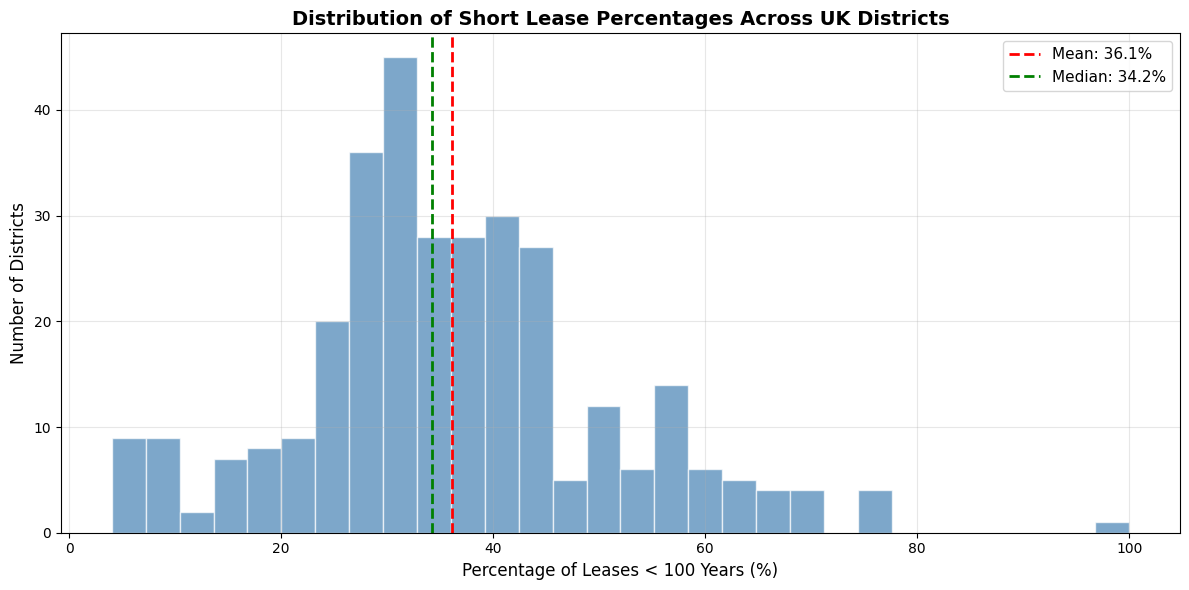

In [20]:
# Create histogram
fig, ax = plt.subplots(figsize=(12, 6))

valid_percentages = df_results['percentage_under_threshold'].dropna()

ax.hist(valid_percentages, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
ax.axvline(valid_percentages.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {valid_percentages.mean():.1f}%')
ax.axvline(valid_percentages.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {valid_percentages.median():.1f}%')

ax.set_xlabel(f'Percentage of Leases < {YEARS_THRESHOLD} Years (%)', fontsize=12)
ax.set_ylabel('Number of Districts', fontsize=12)
ax.set_title(f'Distribution of Short Lease Percentages Across UK Districts', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 15. Top Districts Bar Chart

Visualize the top 20 districts with highest percentages.


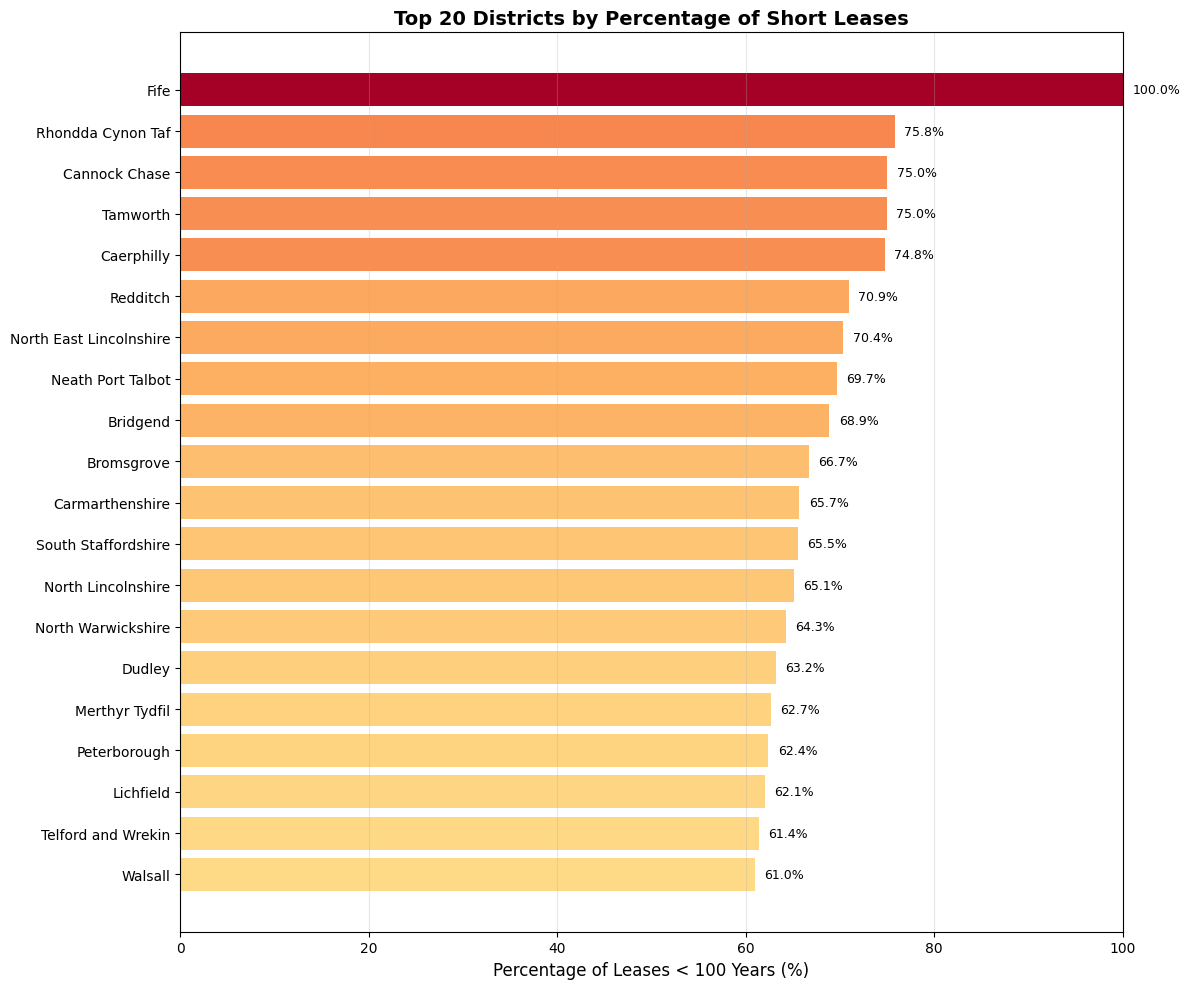

In [21]:
# Plot top 20 districts
fig, ax = plt.subplots(figsize=(12, 10))

top_20 = df_results[df_results['percentage_under_threshold'].notna()].head(20)

# Color bars based on percentage (red for high, yellow for medium, green for low)
colors = plt.cm.RdYlGn_r(top_20['percentage_under_threshold'] / 100)

bars = ax.barh(top_20['district_name'], top_20['percentage_under_threshold'], color=colors)

ax.set_xlabel(f'Percentage of Leases < {YEARS_THRESHOLD} Years (%)', fontsize=12)
ax.set_title(f'Top 20 Districts by Percentage of Short Leases', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest at top

# Add value labels
for bar, value in zip(bars, top_20['percentage_under_threshold']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


---
## 16. Export Results

Save the results to CSV for further analysis.


In [ ]:
# Export to CSV
output_path = DATA_DIR / "lease_expiry_analysis.csv"
df_results.to_csv(output_path, index=False)
print(f"✓ Results exported to: {output_path}")

# Also export the GeoJSON with data for GIS applications
output_geojson_path = DATA_DIR / "lease_expiry_heatmap.geojson"
gdf_merged.to_file(output_geojson_path, driver='GeoJSON')
print(f"✓ GeoJSON exported to: {output_geojson_path}")


---
## 17. Cleanup

Close the MongoDB connection.


In [ ]:
# Close MongoDB connection
client.close()
print("✓ MongoDB connection closed.")
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
